In [24]:
from pathlib import Path
import importlib.util, json, sys
import pandas as pd
import torch
from IPython.display import SVG, display

REPO_ROOT = Path('/home/chenyh/workspace/fluProfiler')
ANALYSIS_DIR = REPO_ROOT / 'paper/Code/Fig4_SCMS_FiLM_20260902'
OUTPUT_ROOT = ANALYSIS_DIR / 'outputs_legacy'
OUTPUT_ROOT.mkdir(exist_ok=True)
spec = importlib.util.spec_from_file_location('fig4_scms_legacy', ANALYSIS_DIR / 'run_vaccine_selection.py')
fig4_scms = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = fig4_scms
spec.loader.exec_module(fig4_scms)


In [25]:
# 原 notebook 的 All.csv 已不在工作区；使用当前 SCMS-FiLM 对应的 HA1 source.csv。
Crick_data = pd.read_csv(REPO_ROOT / 'data/dataset/H3_HA1_v1.0/processed/source.csv')
device = torch.device('cuda:7')
GPU_CACHE_GB = 20
MAX_QUERIES_PER_TASK = 32
TOP_N = 25

season_key = Crick_data['sheet'].astype(str).str.split('-', n=1).str[0]
Crick_early = Crick_data.loc[season_key.astype(int) <= 38].copy()
Crick_2023Feb = Crick_data.loc[season_key == '39'].copy()
Crick_2023Sep = Crick_data.loc[season_key == '40'].copy()
Crick_2024Feb = Crick_data.loc[season_key == '41'].copy()
Crick_2024Sep = Crick_data.loc[season_key == '42'].copy()
Crick_2025Feb = Crick_data.loc[season_key == '43'].copy()
Crick_2025Sep = Crick_data.loc[season_key == '44'].copy()

who_2023Feb = ['A/DARWIN/9/2021 EGG', 'A/DARWIN/6/2021 CELL']
who_2023Sep = ['A/THAILAND/8/2022 EGG', 'A/MASSACHUSETTS/18/2022 CELL']
who_2024Feb = ['A/THAILAND/8/2022 EGG', 'A/MASSACHUSETTS/18/2022 CELL']
who_2024Sep = ['A/CROATIA/10136RV/2023 EGG', 'A/DISTRICTOFCOLUMBIA/27/2023 CELL']
who_2025Feb = ['A/CROATIA/10136RV/2023 EGG', 'A/DISTRICTOFCOLUMBIA/27/2023 CELL']
who_2025Sep = ['A/SINGAPORE/GP20238/2024 EGG', 'A/SYDNEY/1359/2024 CELL']

sup_vaccine, missing_supplementary = fig4_scms.legacy_supplement_candidates(Crick_data)
print('可用于 SCMS-FiLM 的补充候选：', sup_vaccine['serumName'].tolist())
print('缺少 HA1 embedding 的补充候选：', missing_supplementary)


可用于 SCMS-FiLM 的补充候选： ['A/DARWIN/6/2021', 'A/SINGAPORE/GP20238/2024', 'A/SYDNEY/1359/2024', 'A/DISTRICTOFCOLUMBIA/27/2023']
缺少 HA1 embedding 的补充候选： []


In [26]:
def run_legacy_panel(serum, virus, season, panel, who, *, include_serum_name=False, date_weight=False):
    # 与旧 notebook 相同：候选血清 × 当季病毒的完整笛卡尔积。
    test_df = serum.merge(virus, how='cross')
    checkpoint = (REPO_ROOT / 'results/H3_HA1_v1.0/20260827_112805/SCMS-FiLM-H3/season' / season /
                  'subtype/H3N2_seed42/checkpoints/best_model.pth')
    model, vocabs = fig4_scms.load_model(checkpoint, device)
    predictions = fig4_scms.predict_pairs(
        test_df, model, vocabs, device, MAX_QUERIES_PER_TASK, GPU_CACHE_GB
    )
    panel_dir = OUTPUT_ROOT / f'season_{season}_{fig4_scms.SEASONS[season]}'
    panel_dir.mkdir(exist_ok=True)
    predictions.to_csv(panel_dir / 'pair_predictions.csv', index=False)

    # All candidate sera are evaluated against the same complete test-virus set.
    # Only the candidate competition is split by passage, matching the separate
    # WHO EGG and CELL vaccine recommendations.
    rankings = {}
    for passage in ('<CELL>', '<EGG>'):
        label = passage.strip('<>')
        passage_predictions = predictions.loc[predictions['serumPassCat'].eq(passage)].copy()
        if passage_predictions.empty:
            continue
        vaccine = fig4_scms.legacy_rank_candidates(
            passage_predictions, include_serum_name=include_serum_name,
            weight_by_collection_date=date_weight
        )
        vaccine.to_csv(panel_dir / f'vaccine_ranking_{label}.csv', index=False)
        figure = panel_dir / f'Fig4{panel}_{label}.svg'
        passage_who = [name for name in who if name.endswith(f' {label}')]
        fig4_scms.plot_ranking(
            vaccine, season, figure, TOP_N, passage_who, candidate_count=len(vaccine)
        )
        display(SVG(filename=figure))
        rankings[label] = vaccine

    metadata = {
        'workflow': 'legacy Figure 4', 'season': season, 'checkpoint': str(checkpoint),
        'candidate_serum_count': len(serum),
        'candidate_serum_counts_by_passage': serum['serumPassCat'].value_counts().to_dict(),
        'target_virus_count': len(virus), 'pair_count': len(test_df),
        'serum_ranking_includes_name': include_serum_name,
        'weight_by_collection_date': date_weight, 'missing_supplementary': missing_supplementary
    }
    (panel_dir / 'run_metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')
    del model
    if device.type == 'cuda': torch.cuda.empty_cache()
    return rankings, predictions


## 1. Vaccine recommendation

### 1.1 2023-2024 NH

In [27]:
# add supplementary vaccine records
serum_H3_2023Feb, virus_H3_2023Feb = fig4_scms.legacy_candidate_and_virus_tables(Crick_data, '39', sup_vaccine)
print(len(serum_H3_2023Feb), len(virus_H3_2023Feb))

144 195


/tmp/ipykernel_1008414/3190551458.py:2: UserWarning: 13 serumName/serumPassCat candidate(s) have multiple legacy sequences; using the lowest seq_id_a/seq_id_b representative for each.
  serum_H3_2023Feb, virus_H3_2023Feb = fig4_scms.legacy_candidate_and_virus_tables(Crick_data, '39', sup_vaccine)


/home/chenyh/workspace/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:435: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


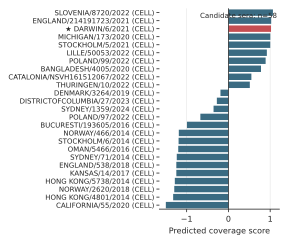

/home/chenyh/workspace/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:435: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


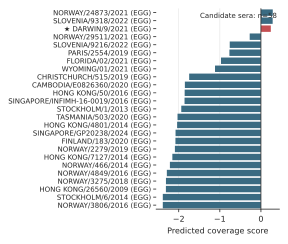

In [28]:
# 旧版仅此面板按 virusDate 加权。
vaccine_2023Feb, test_df_2023Feb = run_legacy_panel(serum_H3_2023Feb, virus_H3_2023Feb, '39', 'A', who_2023Feb, date_weight=True)

### 1.2 2024 SH

In [29]:
# 旧版特殊规则：从 2024Feb 表补入本季 WHO 候选。
who_vac = fig4_scms.legacy_future_who_candidates(Crick_data, [x.rsplit(' ', 1)[0] for x in who_2023Sep])
serum_H3_2023Sep, virus_H3_2023Sep = fig4_scms.legacy_candidate_and_virus_tables(Crick_data, '40', who_vac)
print(len(serum_H3_2023Sep), len(virus_H3_2023Sep))

149 304


/tmp/ipykernel_1008414/931327875.py:3: UserWarning: 13 serumName/serumPassCat candidate(s) have multiple legacy sequences; using the lowest seq_id_a/seq_id_b representative for each.
  serum_H3_2023Sep, virus_H3_2023Sep = fig4_scms.legacy_candidate_and_virus_tables(Crick_data, '40', who_vac)


/home/chenyh/workspace/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:435: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


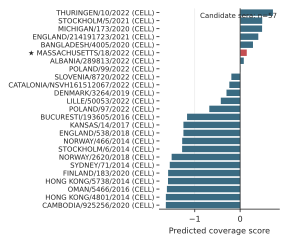

/home/chenyh/workspace/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:435: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


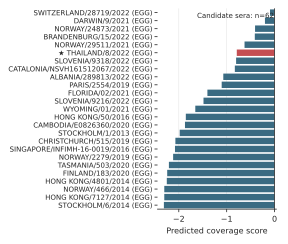

In [30]:
vaccine_2023Sep, test_df_2023Sep = run_legacy_panel(serum_H3_2023Sep, virus_H3_2023Sep, '40', 'B', who_2023Sep)

### 1.3 2024-2025 NH

In [31]:
# Croatia first appears in sheet 42. Add its available EGG and CELL
# candidates to panel C, while retaining panel C's original WHO labels.
season_key = Crick_data['sheet'].astype(str).str.split('-', n=1).str[0]
croatia_2024Feb = Crick_data.loc[
    season_key.eq('42')
    & Crick_data['serumName'].eq('A/CROATIA/10136RV/2023')
    & Crick_data['serumPassCat'].isin(['<EGG>', '<CELL>'])
].copy()
if croatia_2024Feb.empty:
    raise ValueError('Missing sheet-42 A/CROATIA/10136RV/2023 candidates for panel C')
panel_c_extra = pd.concat([sup_vaccine, croatia_2024Feb], ignore_index=True, sort=False)
serum_H3_2024Feb, virus_H3_2024Feb = fig4_scms.legacy_candidate_and_virus_tables(Crick_data, '41', panel_c_extra)
print(len(serum_H3_2024Feb), len(virus_H3_2024Feb))

161 172


/tmp/ipykernel_1008414/3579771610.py:12: UserWarning: 13 serumName/serumPassCat candidate(s) have multiple legacy sequences; using the lowest seq_id_a/seq_id_b representative for each.
  serum_H3_2024Feb, virus_H3_2024Feb = fig4_scms.legacy_candidate_and_virus_tables(Crick_data, '41', panel_c_extra)


In [32]:
# vaccine_2024Feb[vaccine_2024Feb['serumName'] == 'CROATIA/10136RV/2023']

/home/chenyh/workspace/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:435: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


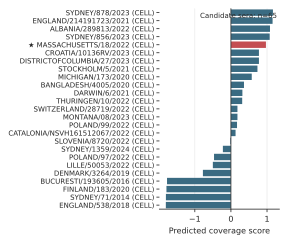

/home/chenyh/workspace/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:435: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


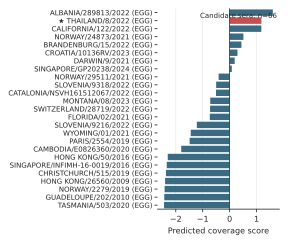

In [33]:
vaccine_2024Feb, test_df_2024Feb = run_legacy_panel(serum_H3_2024Feb, virus_H3_2024Feb, '41', 'C', who_2024Feb)

### 1.4 2025 SH

In [34]:
serum_H3_2024Sep, virus_H3_2024Sep = fig4_scms.legacy_candidate_and_virus_tables(Crick_data, '42', sup_vaccine)
print(len(serum_H3_2024Sep), len(virus_H3_2024Sep))

169 453


/tmp/ipykernel_1008414/2736833970.py:1: UserWarning: 15 serumName/serumPassCat candidate(s) have multiple legacy sequences; using the lowest seq_id_a/seq_id_b representative for each.
  serum_H3_2024Sep, virus_H3_2024Sep = fig4_scms.legacy_candidate_and_virus_tables(Crick_data, '42', sup_vaccine)


In [35]:
# vaccine_2024Sep[vaccine_2024Sep['serumName'] == 'A/CROATIA/10136RV/2023']

/home/chenyh/workspace/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:435: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


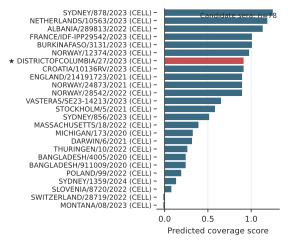

/home/chenyh/workspace/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:435: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


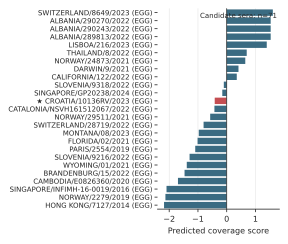

In [36]:
vaccine_2024Sep, test_df_2024Sep = run_legacy_panel(serum_H3_2024Sep, virus_H3_2024Sep, '42', 'D', who_2024Sep, include_serum_name=True)

### 1.5 2025-2026 NH

In [37]:
serum_H3_2025Feb, virus_H3_2025Feb = fig4_scms.legacy_candidate_and_virus_tables(Crick_data, '43', sup_vaccine)
print(len(serum_H3_2025Feb), len(virus_H3_2025Feb))

172 249


/tmp/ipykernel_1008414/2122256159.py:1: UserWarning: 16 serumName/serumPassCat candidate(s) have multiple legacy sequences; using the lowest seq_id_a/seq_id_b representative for each.
  serum_H3_2025Feb, virus_H3_2025Feb = fig4_scms.legacy_candidate_and_virus_tables(Crick_data, '43', sup_vaccine)


/home/chenyh/workspace/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:435: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


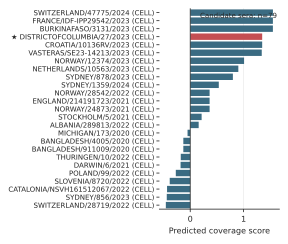

/home/chenyh/workspace/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:435: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


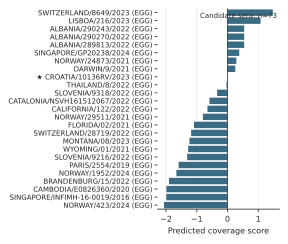

In [38]:
vaccine_2025Feb, test_df_2025Feb = run_legacy_panel(serum_H3_2025Feb, virus_H3_2025Feb, '43', 'E', who_2025Feb, include_serum_name=True)

### 1.6 2026 SH

In [39]:
serum_H3_2025Sep, virus_H3_2025Sep = fig4_scms.legacy_candidate_and_virus_tables(Crick_data, '44', sup_vaccine)
print(len(serum_H3_2025Sep), len(virus_H3_2025Sep))

179 230


/tmp/ipykernel_1008414/978083131.py:1: UserWarning: 17 serumName/serumPassCat candidate(s) have multiple legacy sequences; using the lowest seq_id_a/seq_id_b representative for each.
  serum_H3_2025Sep, virus_H3_2025Sep = fig4_scms.legacy_candidate_and_virus_tables(Crick_data, '44', sup_vaccine)


In [40]:
# vaccine_2025Sep[vaccine_2025Sep['serumName'] == 'A/SYDNEY/1359/2024']
# vaccine_2025Sep[vaccine_2025Sep['serumName'] == 'A/SINGAPORE/GP20238/2024']

/home/chenyh/workspace/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:435: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


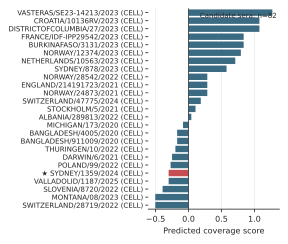

/home/chenyh/workspace/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:435: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


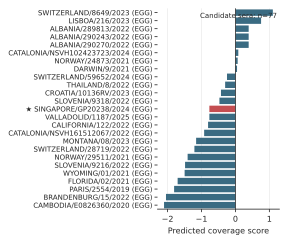

In [41]:
vaccine_2025Sep, test_df_2025Sep = run_legacy_panel(serum_H3_2025Sep, virus_H3_2025Sep, '44', 'F', who_2025Sep, include_serum_name=True)

In [42]:
# WHO ranking summary and cross-season uniform-random baseline.
# This only summarizes the passage-specific rankings already generated above.
import numpy as np

N_RANDOM_DRAWS = 10_000
RANDOM_SEED = 20260906
panel_rankings = [
    ('39', '2023Feb', 'A', vaccine_2023Feb, who_2023Feb),
    ('40', '2023Sep', 'B', vaccine_2023Sep, who_2023Sep),
    ('41', '2024Feb', 'C', vaccine_2024Feb, who_2024Feb),
    ('42', '2024Sep', 'D', vaccine_2024Sep, who_2024Sep),
    ('43', '2025Feb', 'E', vaccine_2025Feb, who_2025Feb),
    ('44', '2025Sep', 'F', vaccine_2025Sep, who_2025Sep),
]

who_rows = []
for season, season_label, panel, rankings, who in panel_rankings:
    for label in ('CELL', 'EGG'):
        ranking = rankings.get(label)
        if ranking is None or ranking.empty:
            raise ValueError(f'{season} {label}: missing passage-specific ranking')
        expected = [name for name in who if name.endswith(f' {label}')]
        if len(expected) != 1:
            raise ValueError(f'{season} {label}: expected one WHO recommendation, got {expected}')
        who_name = expected[0]
        matched = ranking.index[ranking['vaccine'].eq(who_name)]
        if len(matched) != 1:
            raise ValueError(f'{season} {label}: WHO candidate not uniquely ranked: {who_name}')
        n_candidates = len(ranking)
        who_rank = int(matched[0]) + 1
        who_percentile = 1.0 if n_candidates == 1 else 1 - (who_rank - 1) / (n_candidates - 1)
        who_rows.append({
            'season': season, 'season_label': season_label, 'panel': panel,
            'passage': label, 'n_ranked_candidates': n_candidates,
            'WHO_recommended_strain': who_name, 'WHO_rank': who_rank,
            'WHO_percentile': who_percentile,
            'WHO_top1': who_rank <= 1, 'WHO_top3': who_rank <= 3, 'WHO_top5': who_rank <= 5,
        })

who_summary = pd.DataFrame(who_rows)
who_summary.to_csv(OUTPUT_ROOT / 'who_ranking_summary.csv', index=False)
display(who_summary)

# Random baseline: one uniform random candidate per season x passage,
# aggregated across all evaluations and repeated with a fixed seed.
rng = np.random.default_rng(RANDOM_SEED)
random_hits = {k: np.zeros(N_RANDOM_DRAWS, dtype=int) for k in (1, 3, 5)}
for n_candidates in who_summary['n_ranked_candidates']:
    random_rank = rng.integers(1, int(n_candidates) + 1, size=N_RANDOM_DRAWS)
    for k in random_hits:
        random_hits[k] += random_rank <= min(k, int(n_candidates))

baseline_rows = []
for k, hit_counts in random_hits.items():
    observed_count = int(who_summary[f'WHO_top{k}'].sum())
    baseline_rows.append({
        'metric': f'Top{k}', 'n_consultation_passage_evaluations': len(who_summary),
        'WHO_hit_count': observed_count, 'WHO_hit_rate': observed_count / len(who_summary),
        'random_hit_count_mean': hit_counts.mean(),
        'random_hit_count_2.5pct': np.quantile(hit_counts, 0.025),
        'random_hit_count_97.5pct': np.quantile(hit_counts, 0.975),
        'empirical_p_value': (hit_counts >= observed_count).mean(),
        'n_random_draws': N_RANDOM_DRAWS, 'random_seed': RANDOM_SEED,
    })

random_baseline = pd.DataFrame(baseline_rows)
random_baseline.to_csv(OUTPUT_ROOT / 'who_vs_random_baseline.csv', index=False)
display(random_baseline)


,season,season_label,panel,passage,n_ranked_candidates,WHO_recommended_strain,WHO_rank,WHO_percentile,WHO_top1,WHO_top3,WHO_top5
0,39,2023Feb,A,CELL,58,A/DARWIN/6/2021 CELL,3,0.964912,False,True,True
1,39,2023Feb,A,EGG,58,A/DARWIN/9/2021 EGG,3,0.964912,False,True,True
2,40,2023Sep,B,CELL,57,A/MASSACHUSETTS/18/2022 CELL,6,0.910714,False,False,False
3,40,2023Sep,B,EGG,62,A/THAILAND/8/2022 EGG,6,0.918033,False,False,False
4,41,2024Feb,C,CELL,65,A/MASSACHUSETTS/18/2022 CELL,5,0.937500,False,False,True
5,41,2024Feb,C,EGG,66,A/THAILAND/8/2022 EGG,2,0.984615,False,True,True
6,42,2024Sep,D,CELL,78,A/DISTRICTOFCOLUMBIA/27/2023 CELL,7,0.922078,False,False,False
7,42,2024Sep,D,EGG,71,A/CROATIA/10136RV/2023 EGG,12,0.842857,False,False,False
8,43,2025Feb,E,CELL,79,A/DISTRICTOFCOLUMBIA/27/2023 CELL,4,0.961538,False,False,True
9,43,2025Feb,E,EGG,73,A/CROATIA/10136RV/2023 EGG,9,0.888889,False,False,False


,metric,n_consultation_passage_evaluations,WHO_hit_count,WHO_hit_rate,random_hit_count_mean,random_hit_count_2.5pct,random_hit_count_97.5pct,empirical_p_value,n_random_draws,random_seed
0,Top1,12,0,0.000000,0.1810,0.0,1.0,1.0000,10000,20260906
1,Top3,12,3,0.250000,0.5284,0.0,2.0,0.0132,10000,20260906
2,Top5,12,5,0.416667,0.8914,0.0,3.0,0.0009,10000,20260906


## 2. Manuscript Figure 4 — prospective ranking of WHO vaccine recommendations

Panels A–F display all eligible candidate sera within the separate CELL and EGG competitions for each consultation. Candidates are ordered by predicted coverage score (higher is better), and the WHO-recommended candidate is marked with a star and its exact rank. Panel G compares the observed WHO Top-*k* hit rates with the season- and passage-matched uniform-random baseline.


In [ ]:
# Manuscript Figure 4: all-candidate ranking curves plus the random baseline.
# This cell reads the completed legacy outputs, so it does not rerun SCMS-FiLM inference.
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG4_OUTPUT = OUTPUT_ROOT / 'Fig4_manuscript'
FIG4_OUTPUT.mkdir(exist_ok=True)

rank_summary = pd.read_csv(OUTPUT_ROOT / 'who_ranking_summary.csv')
baseline_summary = pd.read_csv(OUTPUT_ROOT / 'who_vs_random_baseline.csv')
season_order = ['39', '40', '41', '42', '43', '44']
passage_colors = {'CELL': '#2E6F8E', 'EGG': '#C99516'}
who_color = '#C44E52'
panel_letters = dict(zip(season_order, 'ABCDEF'))

plot_rows = []
for season in season_order:
    season_rows = rank_summary.loc[rank_summary['season'].astype(str).eq(season)]
    for passage in ('CELL', 'EGG'):
        who_row = season_rows.loc[season_rows['passage'].eq(passage)].iloc[0]
        ranking_path = OUTPUT_ROOT / f"season_{season}_{who_row['season_label']}" / f'vaccine_ranking_{passage}.csv'
        ranking = pd.read_csv(ranking_path).sort_values('coverage_score', ascending=False, kind='stable').reset_index(drop=True)
        ranking['rank'] = np.arange(1, len(ranking) + 1)
        ranking['season'] = season
        ranking['season_label'] = who_row['season_label']
        ranking['panel'] = who_row['panel']
        ranking['passage'] = passage
        ranking['is_who'] = ranking['vaccine'].eq(who_row['WHO_recommended_strain'])
        if ranking['is_who'].sum() != 1:
            raise ValueError(f"{season} {passage}: WHO candidate not uniquely present in {ranking_path}")
        plot_rows.append(ranking)
fig4_ranking_data = pd.concat(plot_rows, ignore_index=True)
fig4_ranking_data.to_csv(FIG4_OUTPUT / 'Fig4_all_candidate_rankings.csv', index=False)

fig = plt.figure(figsize=(11.4, 12.0), dpi=300)
grid = GridSpec(4, 2, figure=fig, height_ratios=[1, 1, 1, 0.92], hspace=0.55, wspace=0.30)

for index, season in enumerate(season_order):
    ax = fig.add_subplot(grid[index // 2, index % 2])
    subset = fig4_ranking_data.loc[fig4_ranking_data['season'].eq(season)]
    max_rank = int(subset['rank'].max())
    season_label = subset['season_label'].iloc[0]

    for passage in ('CELL', 'EGG'):
        data = subset.loc[subset['passage'].eq(passage)].sort_values('rank')
        ax.plot(
            data['coverage_score'], data['rank'], color=passage_colors[passage],
            lw=0.8, alpha=0.45, zorder=1,
        )
        ax.scatter(
            data['coverage_score'], data['rank'], s=11, color=passage_colors[passage],
            alpha=0.72, linewidths=0, zorder=2,
        )
        who = data.loc[data['is_who']].iloc[0]
        ax.scatter(
            who['coverage_score'], who['rank'], s=75, marker='*', color=who_color,
            edgecolor='white', linewidth=0.55, zorder=5,
        )
        label_offset = 5 if passage == 'CELL' else -5
        horizontal_alignment = 'left' if passage == 'CELL' else 'right'
        ax.annotate(
            f"{passage}: #{int(who['rank'])}/{len(data)}", xy=(who['coverage_score'], who['rank']),
            xytext=(label_offset, -8), textcoords='offset points', ha=horizontal_alignment,
            va='top', fontsize=7.4, color=who_color, fontweight='bold', zorder=6,
        )

    ax.set_title(f"{panel_letters[season]}  {season_label}", loc='left', fontsize=11, fontweight='bold', pad=5)
    ax.set_xlabel('Predicted coverage score', fontsize=8.5)
    ax.set_ylabel('Candidate rank' if index % 2 == 0 else '', fontsize=8.5)
    ax.set_ylim(max_rank + 2, 0)
    ax.set_yticks([1, max_rank])
    ax.set_yticklabels(['1', str(max_rank)])
    ax.xaxis.grid(True, color='#E7E7E7', lw=0.65)
    ax.yaxis.grid(False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=7.5, width=0.8, length=3)

legend_handles = [
    Line2D([0], [0], color=passage_colors['CELL'], marker='o', markersize=4, lw=1, label='CELL candidates'),
    Line2D([0], [0], color=passage_colors['EGG'], marker='o', markersize=4, lw=1, label='EGG candidates'),
    Line2D([0], [0], marker='*', color='none', markerfacecolor=who_color, markeredgecolor='white', markersize=10, label='WHO recommendation'),
]
fig.legend(handles=legend_handles, ncol=3, frameon=False, fontsize=8.5, loc='upper center', bbox_to_anchor=(0.5, 0.992))

# Panel G: observed WHO hit rate versus the matched uniform-random baseline.
ax = fig.add_subplot(grid[3, :])
metrics = ['Top1', 'Top3', 'Top5']
base = baseline_summary.set_index('metric').loc[metrics].reset_index()
x = np.arange(len(base))
width = 0.32
n_evaluations = int(base['n_consultation_passage_evaluations'].iloc[0])
who_rates = base['WHO_hit_rate'].to_numpy()
random_rates = (base['random_hit_count_mean'] / n_evaluations).to_numpy()
random_low = (base['random_hit_count_2.5pct'] / n_evaluations).to_numpy()
random_high = (base['random_hit_count_97.5pct'] / n_evaluations).to_numpy()

ax.bar(x - width / 2, who_rates, width, color=who_color, label='WHO recommendation', zorder=3)
ax.bar(
    x + width / 2, random_rates, width, color='#A9A9A9', label='Uniform-random baseline', zorder=3,
    yerr=np.vstack([random_rates - random_low, random_high - random_rates]),
    capsize=3, error_kw={'lw': 0.9, 'capthick': 0.9, 'ecolor': '#555555'},
)
for xpos, rate, count in zip(x - width / 2, who_rates, base['WHO_hit_count']):
    ax.text(xpos, rate + 0.025, f'{int(count)}/{n_evaluations}', ha='center', va='bottom', fontsize=8, fontweight='bold', color=who_color)
for xpos, p_value in zip(x, base['empirical_p_value']):
    ax.text(xpos, 0.53, f'P = {p_value:.4f}' if p_value < 0.01 else f'P = {p_value:.3f}', ha='center', va='top', fontsize=7.5, color='#333333')
ax.set_title('G  WHO ranking performance versus random selection', loc='left', fontsize=11, fontweight='bold', pad=5)
ax.set_xticks(x, ['Top-1', 'Top-3', 'Top-5'])
ax.set_ylabel('Hit rate across 12 evaluations')
ax.set_ylim(0, 0.56)
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
ax.yaxis.grid(True, color='#E7E7E7', lw=0.65, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=8.5, loc='upper left')
ax.tick_params(labelsize=8, width=0.8, length=3)

fig.suptitle('Prospective ranking of WHO H3N2 vaccine recommendations', y=0.999, fontsize=13, fontweight='bold')
for extension in ('svg', 'pdf', 'png'):
    fig.savefig(FIG4_OUTPUT / f'Fig4_WHO_candidate_ranking_overview.{extension}', dpi=300, bbox_inches='tight')
plt.show()

print(f'Wrote Figure 4 overview and plotting data to: {FIG4_OUTPUT}')
